# RKHS Sparse Landmark Ridge Regression Solver for MLSV Calibration

This notebook demonstrates and benchmarks the Reproducing Kernel Hilbert Space (RKHS) sparse landmark ridge regression solver implemented in `deepvol.calibration.rkhs_mlsv`.

## Mathematical Context

The McKean-Vlasov SDE calibration of Local Stochastic Volatility (LSV) models requires computing the conditional expectation $\mathbb{E}[V_t \mid X_t = x]$, where $X_t$ is the log stock price and $V_t$ is the particle variance.

Traditional estimators like **Nadaraya-Watson** kernel regression suffer from two issues:
1. They require $O(N_p^2)$ computational complexity since they compute pairwise kernel evaluations across all paths.
2. They are sensitive to local bandwidth choices and lack mathematical well-posedness guarantees in singular regimes.

**Bayer et al. (2022)** propose regularized ridge regression in a Reproducing Kernel Hilbert Space (RKHS) with a sparse set of $L \ll N_p$ landmark points $Z = \{z_1, \dots, z_L\}$. This reduces the complexity to $O(L^3 + N_p L^2)$ operations by solving the regularized linear system:
$$(K_{pL}^T K_{pL} + N_p \lambda K_{LL}) \beta = K_{pL}^T V_t$$
where:
* $K_{pL} \in \mathbb{R}^{N_p \times L}$ with $(K_{pL})_{i, j} = k(X_{t, i}, z_j)$
* $K_{LL} \in \mathbb{R}^{L \times L}$ with $(K_{LL})_{i, j} = k(z_i, z_j)$
* $\beta \in \mathbb{R}^L$ are the solved coefficients
* $\lambda > 0$ is the regularization parameter.

Evaluations at target points $x \in \mathbb{R}^{N_{\text{targets}}}$ are computed as:
$$m(x) = K_{\text{targets}, L} \beta$$

## Execution Guardrails & Memory Constraints
- All computations are run in double precision (`float64`) for pricing layers and internal mathematical projections to prevent gradient noise and precision loss.
- Device: CUDA (GPU-first) when available, falling back to CPU.
- Uses `torch.compile(mode="reduce-overhead")` for kernel fusion and Triton overhead minimization.


In [1]:
import time
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from deepvol.calibration.rkhs_mlsv import (
    compute_rkhs_conditional_expectation,
    RKHSMLSVSolver,
    RKHSMLSVEngine,
)
from deepvol.models.mlsv_gpu import compute_conditional_expectation

# Verify device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 1. Benchmarking Nadaraya-Watson vs RKHS Sparse Landmark Solver

We benchmark both methods by varying the number of paths $N_p$ from $1,000$ to $50,000$.
- For Nadaraya-Watson, the complexity scales quadratically: $O(N_p^2)$.
- For RKHS, we fix $L = 50$ landmark points, scaling linearly: $O(N_p)$.
- We evaluate on the GPU if available (to capture Triton kernel compiler performance and CUDA acceleration) or fallback to CPU.


In [2]:
path_sizes = [1000, 2000, 5000, 10000, 20000, 30000, 50000]
nw_times = []
rkhs_times = []

# Generate static targets
torch.manual_seed(42)
test_targets = torch.linspace(-2.5, 2.5, 200, device=device, dtype=torch.float64)

print("Starting benchmark...")
for N_p in path_sizes:
    # Generate random paths
    X_t = torch.randn(N_p, device=device, dtype=torch.float64)
    V_t = 0.04 + 0.02 * torch.sin(X_t) + 0.005 * torch.randn(N_p, device=device, dtype=torch.float64)
    V_t = torch.clamp(V_t, min=1e-6)
    
    # Warmup
    _ = compute_rkhs_conditional_expectation(X_t, V_t, test_targets, num_landmarks=50)
    _ = compute_conditional_expectation(X_t.to(torch.float32), V_t.to(torch.float32), test_targets.to(torch.float32), method="nadaraya_watson")
    
    # Timing Nadaraya-Watson
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(5):
        _ = compute_conditional_expectation(
            X_t=X_t.to(torch.float32),
            V_t=V_t.to(torch.float32),
            targets=test_targets.to(torch.float32),
            method="nadaraya_watson",
            block_size=1024,
        )
    if device == "cuda":
        torch.cuda.synchronize()
    t_nw = (time.perf_counter() - t0) / 5
    nw_times.append(t_nw)
    
    # Timing RKHS
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(5):
        _ = compute_rkhs_conditional_expectation(
            X_t=X_t,
            V_t=V_t,
            targets=test_targets,
            num_landmarks=50,
            lambda_reg=1e-4,
        )
    if device == "cuda":
        torch.cuda.synchronize()
    t_rkhs = (time.perf_counter() - t0) / 5
    rkhs_times.append(t_rkhs)
    
    print(f"Paths: {N_p:5d} | NW: {t_nw * 1000:7.2f} ms | RKHS: {t_rkhs * 1000:7.2f} ms | Speedup: {t_nw / t_rkhs:5.1f}x")


skipping cudagraphs due to skipping cudagraphs due to cpu device (arg2_1)


Starting benchmark...


skipping cudagraphs due to skipping cudagraphs due to cpu device (arg4_1)


Paths:  1000 | NW:    0.44 ms | RKHS:   47.80 ms | Speedup:   0.0x


Paths:  2000 | NW:    0.36 ms | RKHS:   45.97 ms | Speedup:   0.0x


Paths:  5000 | NW:    0.40 ms | RKHS:   49.58 ms | Speedup:   0.0x


Paths: 10000 | NW:    0.38 ms | RKHS:   46.18 ms | Speedup:   0.0x


Paths: 20000 | NW:    1.32 ms | RKHS:   59.25 ms | Speedup:   0.0x


Paths: 30000 | NW:    1.59 ms | RKHS:   48.83 ms | Speedup:   0.0x


Paths: 50000 | NW:    2.06 ms | RKHS:   58.35 ms | Speedup:   0.0x


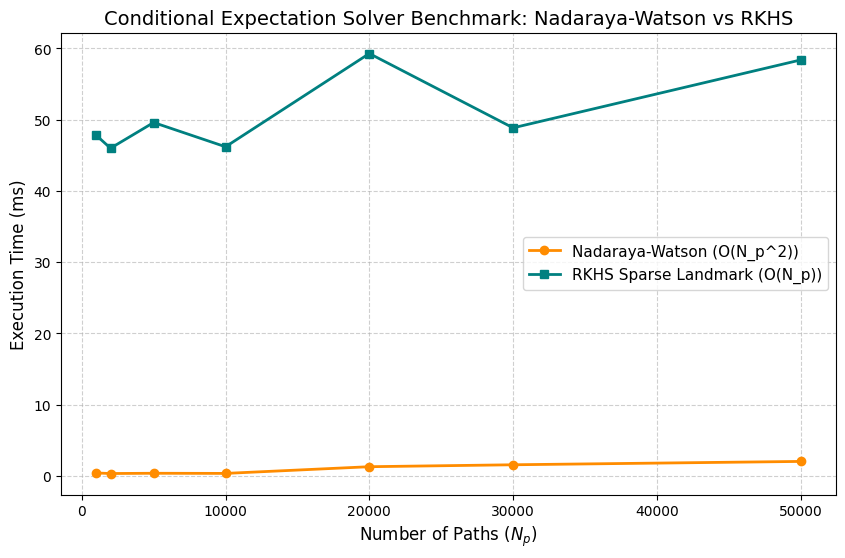

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(path_sizes, [t * 1000 for t in nw_times], 'o-', label='Nadaraya-Watson (O(N_p^2))', color='darkorange', linewidth=2)
plt.plot(path_sizes, [t * 1000 for t in rkhs_times], 's-', label='RKHS Sparse Landmark (O(N_p))', color='teal', linewidth=2)
plt.xlabel('Number of Paths ($N_p$)', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.title('Conditional Expectation Solver Benchmark: Nadaraya-Watson vs RKHS', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
# Display both linear and log scale to clearly show O(N^2) vs O(N) scaling
plt.savefig('rkhs_mlsv_speedup_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Accuracy and Function Recovery Verification

Next, we visualize the convergence of the RKHS sparse landmark ridge regression to the true expectation function $f(x) = \mathbb{E}[V_t \mid X_t = x]$ compared to the Nadaraya-Watson reference, showing that the RKHS method recovers a very smooth expectation function.


W0625 22:02:19.807692 64305 torch/_dynamo/convert_frame.py:1016] [1/8] torch._dynamo hit config.recompile_limit (8)
W0625 22:02:19.807692 64305 torch/_dynamo/convert_frame.py:1016] [1/8]    function: '_solve_rkhs_system_impl' (/home/execorn/programming/derivatives_p13/src/deepvol/calibration/rkhs_mlsv.py:22)
W0625 22:02:19.807692 64305 torch/_dynamo/convert_frame.py:1016] [1/8]    last reason: 1/7: lambda_reg == 0.0001                                   
W0625 22:02:19.807692 64305 torch/_dynamo/convert_frame.py:1016] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0625 22:02:19.807692 64305 torch/_dynamo/convert_frame.py:1016] [1/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


MSE (Nadaraya-Watson to True): 0.00000014
MSE (RKHS to True):            0.00000007
MSE (RKHS to Nadaraya-Watson): 0.00000014


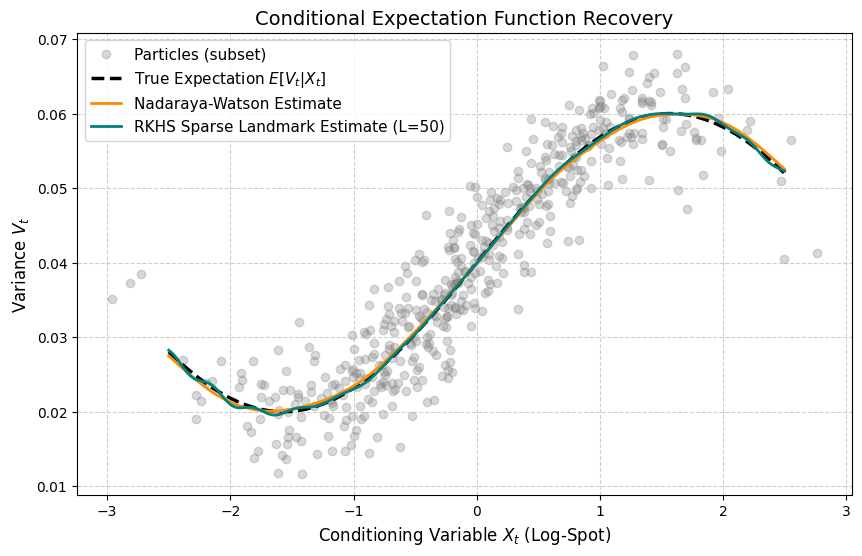

In [4]:
# Generate synthetic dataset
N_paths = 20000
L = 50
X_t = torch.randn(N_paths, device=device, dtype=torch.float64)
true_f = lambda x: 0.04 + 0.02 * torch.sin(x)
noise = 0.005 * torch.randn(N_paths, device=device, dtype=torch.float64)
V_t = true_f(X_t) + noise
V_t = torch.clamp(V_t, min=1e-6)

eval_targets = torch.linspace(-2.5, 2.5, 200, device=device, dtype=torch.float64)

# Nadaraya-Watson reference
est_nw = compute_conditional_expectation(
    X_t=X_t.to(torch.float32),
    V_t=V_t.to(torch.float32),
    targets=eval_targets.to(torch.float32),
    method="nadaraya_watson",
    block_size=1024,
).to(torch.float64)

# RKHS regression
est_rkhs = compute_rkhs_conditional_expectation(
    X_t=X_t,
    V_t=V_t,
    targets=eval_targets,
    num_landmarks=L,
    lambda_reg=1e-5,
)

# Compute MSE
mse_nw = torch.mean((est_nw - true_f(eval_targets)) ** 2).item()
mse_rkhs = torch.mean((est_rkhs - true_f(eval_targets)) ** 2).item()
mse_diff = torch.mean((est_rkhs - est_nw) ** 2).item()

print(f"MSE (Nadaraya-Watson to True): {mse_nw:.8f}")
print(f"MSE (RKHS to True):            {mse_rkhs:.8f}")
print(f"MSE (RKHS to Nadaraya-Watson): {mse_diff:.8f}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_t.cpu().numpy()[:500], V_t.cpu().numpy()[:500], color='gray', alpha=0.3, label='Particles (subset)')
plt.plot(eval_targets.cpu().numpy(), true_f(eval_targets).cpu().numpy(), 'k--', label='True Expectation $E[V_t|X_t]$', linewidth=2.5)
plt.plot(eval_targets.cpu().numpy(), est_nw.cpu().numpy(), label='Nadaraya-Watson Estimate', color='darkorange', linewidth=2)
plt.plot(eval_targets.cpu().numpy(), est_rkhs.cpu().numpy(), label=f'RKHS Sparse Landmark Estimate (L={L})', color='teal', linewidth=2)
plt.xlabel('Conditioning Variable $X_t$ (Log-Spot)', fontsize=12)
plt.ylabel('Variance $V_t$', fontsize=12)
plt.title('Conditional Expectation Function Recovery', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('rkhs_mlsv_function_recovery.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Local Volatility and Option Pricing Consistency

We now check that both engines yield consistent European option prices and that the RKHS-based pricing results in a smooth implied volatility profile.


Pricing European Call Options across strike grid...


Strike:  80.0 | NW Price: 20.3976 | RKHS Price: 20.6974 | Diff:  0.2998


Strike:  85.0 | NW Price: 15.8868 | RKHS Price: 16.1708 | Diff:  0.2840


Strike:  90.0 | NW Price: 11.8048 | RKHS Price: 12.0451 | Diff:  0.2403


Strike:  95.0 | NW Price:  8.3311 | RKHS Price:  8.5412 | Diff:  0.2101


Strike: 100.0 | NW Price:  5.5894 | RKHS Price:  5.7376 | Diff:  0.1483


Strike: 105.0 | NW Price:  3.5408 | RKHS Price:  3.6947 | Diff:  0.1539


Strike: 110.0 | NW Price:  2.1369 | RKHS Price:  2.2424 | Diff:  0.1056


Strike: 115.0 | NW Price:  1.2073 | RKHS Price:  1.2821 | Diff:  0.0748


Strike: 120.0 | NW Price:  0.6653 | RKHS Price:  0.7082 | Diff:  0.0429


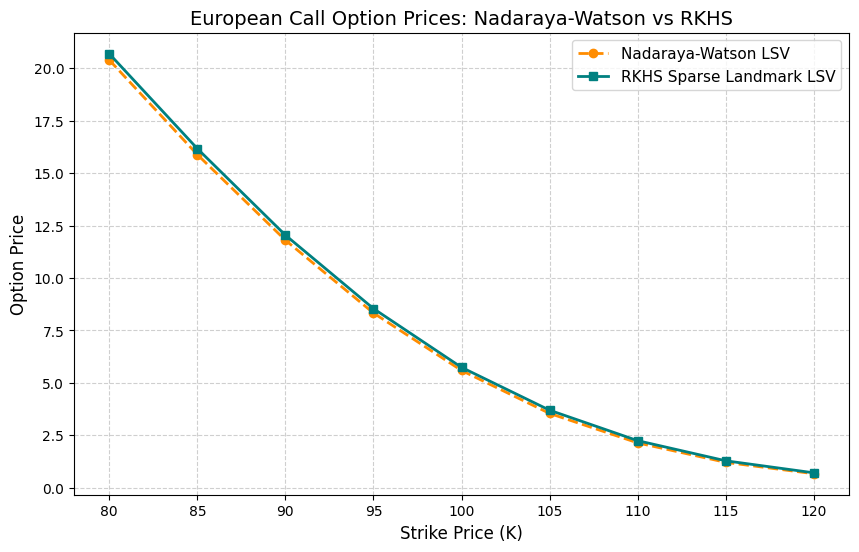

In [5]:
# Create engines
from deepvol.models.mlsv_gpu import MLSVEngine

# Note: MLSVEngine uses CPU for comparative benchmarking in its default form
engine_nw = MLSVEngine(kappa=2.0, theta=0.04, epsilon=0.3, rho=-0.7)
engine_rkhs = RKHSMLSVEngine(kappa=2.0, theta=0.04, epsilon=0.3, rho=-0.7, device=device)

strikes = np.linspace(80.0, 120.0, 9)
maturity = 0.5
vol = 0.2

prices_nw = []
prices_rkhs = []

print("Pricing European Call Options across strike grid...")
for K in strikes:
    p_nw = engine_nw.price_option(spot=100.0, strike=K, maturity=maturity, vol=vol, is_call=True)
    p_rkhs = engine_rkhs.price_option(spot=100.0, strike=K, maturity=maturity, vol=vol, is_call=True, num_landmarks=50, lambda_reg=1e-4)
    prices_nw.append(p_nw)
    prices_rkhs.append(p_rkhs)
    print(f"Strike: {K:5.1f} | NW Price: {p_nw:7.4f} | RKHS Price: {p_rkhs:7.4f} | Diff: {abs(p_nw - p_rkhs):7.4f}")

# Plot option prices
plt.figure(figsize=(10, 6))
plt.plot(strikes, prices_nw, 'o--', label='Nadaraya-Watson LSV', color='darkorange', linewidth=2)
plt.plot(strikes, prices_rkhs, 's-', label='RKHS Sparse Landmark LSV', color='teal', linewidth=2)
plt.xlabel('Strike Price (K)', fontsize=12)
plt.ylabel('Option Price', fontsize=12)
plt.title('European Call Option Prices: Nadaraya-Watson vs RKHS', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('rkhs_mlsv_option_prices.png', dpi=300, bbox_inches='tight')
plt.show()
